# IoT Device Fingerprinting & Unsupervised Rogue Device Detection

## Project Overview
This notebook implements an eight-layer IoT security framework combining
traffic-based device fingerprinting, supervised classification of known devices,
and unsupervised rogue device detection.

## Objectives
- ≥85% classification accuracy for known IoT devices
- ≥95% rogue detection sensitivity
- <5% false positive rate
- Zero Trust aligned detection–decision–enforcement pipeline

## 8-Layer Architecture
1. Data Collection
2. Feature Engineering
3. Supervised Fingerprinting
4. Unsupervised Rogue Detection
5. Decision Fusion
6. SIEM-style Alerting
7. Segmentation & Enforcement
8. Continuous Learning

# Install libraries
# !pip install xgboost tensorflow scikit-learn seaborn imbalanced-learn

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors, BallTree

from xgboost import XGBClassifier

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Input
import os
from google.colab import drive

In [2]:
# ── Standard imports ──────────────────────────────────────────
import os
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler

# ── Google Drive ───────────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

# ── Paths ─────────────────────────────────────────────────────
BASE = '/content/drive/MyDrive/Capstone_IoT'
RAW  = os.path.join(BASE, 'Data/Raw')

# ── Load data ─────────────────────────────────────────────────
df = pd.concat(
    [
        pd.read_csv(os.path.join(RAW, "Merged01.csv")),
        #pd.read_csv(os.path.join(RAW, "Merged02.csv")),
        #pd.read_csv(os.path.join(RAW, "Merged03.csv")),
        #pd.read_csv(os.path.join(RAW, "Merged04.csv")),
        #pd.read_csv(os.path.join(RAW, "Merged05.csv")),
        #pd.read_csv(os.path.join(RAW, "Merged06.csv")),
        #pd.read_csv(os.path.join(RAW, "Merged07.csv")),
        #pd.read_csv(os.path.join(RAW, "Merged08.csv")),
        #pd.read_csv(os.path.join(RAW, "Merged09.csv")),
        #pd.read_csv(os.path.join(RAW, "Merged10.csv")),
    ],
    ignore_index=True
)

print(df.shape)
display(df.head())

# ── Encode & scale ────────────────────────────────────────────
label_encoder = LabelEncoder()
df['Label_enc'] = label_encoder.fit_transform(df['Label'])

X = df.drop(columns=['Label', 'Label_enc']).select_dtypes(include=[np.number])
y = df['Label_enc']

X = X.replace([np.inf, -np.inf], np.nan)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X.fillna(0))

print("Scaled shape:", X_scaled.shape)

Mounted at /content/drive
(712311, 40)


,Header_Length,Protocol Type,Time_To_Live,Rate,fin_flag_number,syn_flag_number,rst_flag_number,psh_flag_number,ack_flag_number,ece_flag_number,...,Tot sum,Min,Max,AVG,Std,Tot size,IAT,Number,Variance,Label
0,19.92,6,63.36,25893.962218,0.0,0.0,0.0,0.99,0.99,0.0,...,6421,60,481,64.21,42.100000,64.21,0.000039,100,1772.410000,DDOS-PSHACK_FLOOD
1,0.00,47,64.00,3703.841331,0.0,0.0,0.0,0.00,0.00,0.0,...,57320,98,578,573.20,48.000000,573.20,0.000271,100,2304.000000,MIRAI-GREIP_FLOOD
2,7.92,17,65.91,19673.095685,0.0,0.0,0.0,0.00,0.00,0.0,...,6010,60,70,60.10,1.000000,60.10,0.000057,100,1.000000,DOS-UDP_FLOOD
3,20.40,6,110.50,261.664826,0.1,0.0,0.3,0.20,0.40,0.0,...,2223,54,1500,222.30,451.596686,222.30,0.004766,10,203939.566667,DNS_SPOOFING
4,0.32,1,63.96,28944.199848,0.0,0.0,0.0,0.00,0.01,0.0,...,6006,60,66,60.06,0.600000,60.06,0.000035,100,0.360000,DDOS-ICMP_FLOOD


Scaled shape: (712311, 39)


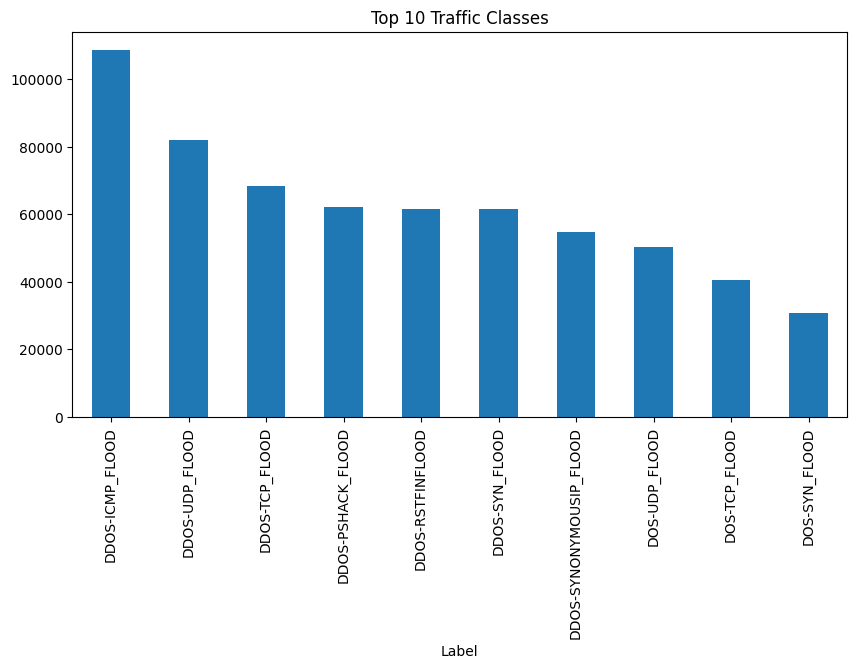

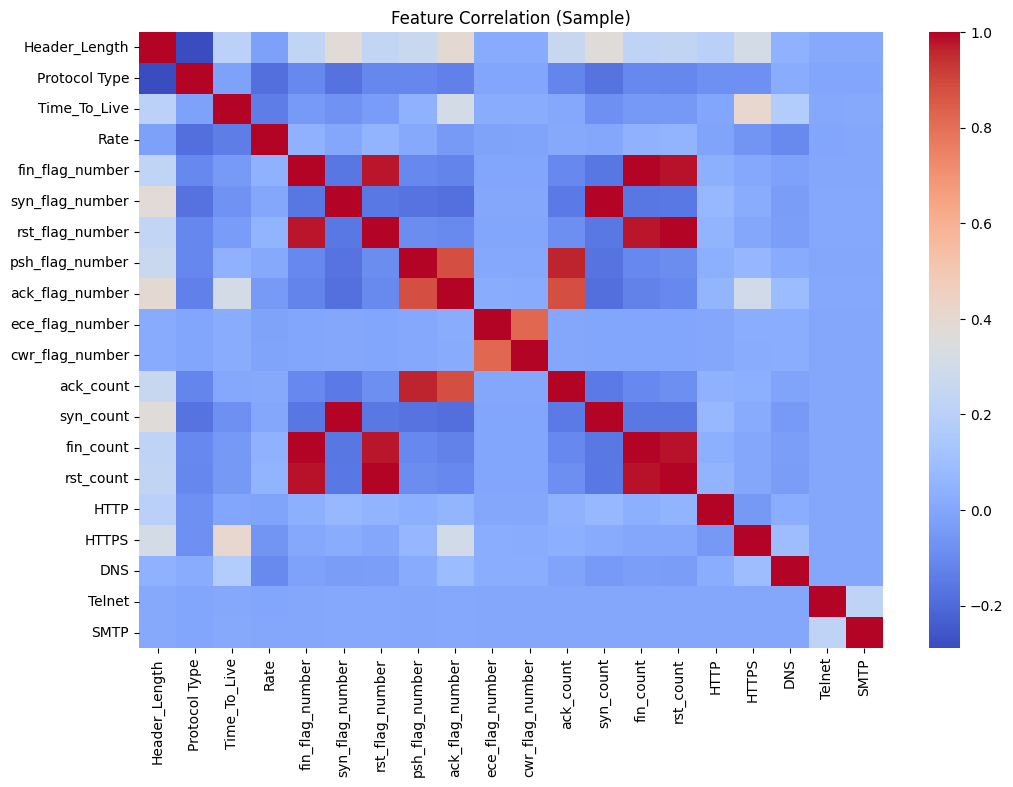

In [3]:
plt.figure(figsize=(10,5))
df['Label'].value_counts().head(10).plot(kind='bar')
plt.title("Top 10 Traffic Classes")
plt.show()

plt.figure(figsize=(12,8))
sns.heatmap(pd.DataFrame(X).corr().iloc[:20,:20], cmap='coolwarm')
plt.title("Feature Correlation (Sample)")
plt.show()

In [4]:
# Layer 3 – Supervised Learning (Fingerprinting)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.25,
    stratify=y,
    random_state=42
)

# Random Forest
rf = RandomForestClassifier(
    n_estimators=200,
    n_jobs=-1,
    random_state=42
)
rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)
print("Random Forest:")
print(classification_report(y_test, rf_pred))

# XGBoost
xgb = XGBClassifier(
    objective="multi:softprob",
    eval_metric="mlogloss",
    max_depth=6,
    n_estimators=200,
    tree_method="hist",
    random_state=42
)
xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)
print("XGBoost:")
print(classification_report(y_test, xgb_pred))

Random Forest:
              precision    recall  f1-score   support

           0       1.00      0.10      0.18        10
           1       0.77      0.90      0.83      4144
           2       0.67      0.10      0.17        21
           3       1.00      0.06      0.11        18
           4       0.99      0.98      0.99      1077
           5       0.81      0.67      0.74       104
           6       1.00      1.00      1.00     27166
           7       0.98      0.98      0.98      1696
           8       1.00      1.00      1.00     15543
           9       1.00      1.00      1.00     15413
          10       0.60      0.88      0.71        88
          11       0.52      0.53      0.53     13687
          12       0.49      0.52      0.51     15365
          13       0.69      0.73      0.71     17072
          14       0.78      0.81      0.79     20503
          15       0.99      0.99      0.99      1066
          16       0.67      0.04      0.07        51
          17

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


XGBoost:
              precision    recall  f1-score   support

           0       0.50      0.10      0.17        10
           1       0.78      0.89      0.83      4144
           2       0.60      0.14      0.23        21
           3       0.33      0.06      0.10        18
           4       0.99      0.98      0.99      1077
           5       0.58      0.63      0.61       104
           6       1.00      1.00      1.00     27166
           7       0.99      0.98      0.98      1696
           8       1.00      1.00      1.00     15543
           9       1.00      1.00      1.00     15413
          10       0.64      0.77      0.70        88
          11       0.46      0.72      0.57     13687
          12       0.52      0.42      0.46     15365
          13       0.69      0.86      0.77     17072
          14       0.74      0.93      0.82     20503
          15       0.99      0.99      0.99      1066
          16       0.47      0.14      0.21        51
          17      

In [5]:
# ===============================
# Layer 4 – Unsupervised Rogue Detection (WINDOWS-SAFE)
# ===============================

# -------------------------------
# Safety checks
# -------------------------------
assert 'df' in globals(), "df not defined"
assert 'X_scaled' in globals(), "X_scaled not defined"
assert 'Label' in df.columns, "Label column missing"

# -------------------------------
# BENIGN subset
# -------------------------------
benign_idx = df['Label'] == 'BENIGN'
X_benign = X_scaled[benign_idx]

# Limit benign samples for AE stability
MAX_AE_SAMPLES = 100_000
if X_benign.shape[0] > MAX_AE_SAMPLES:
    rng = np.random.default_rng(42)
    sample_idx = rng.choice(
        X_benign.shape[0],
        size=MAX_AE_SAMPLES,
        replace=False
    )
    X_benign_train = X_benign[sample_idx]
else:
    X_benign_train = X_benign

# -------------------------------
# KMeans (distance anomaly)
# -------------------------------
kmeans = KMeans(n_clusters=1, random_state=42)
kmeans.fit(X_benign_train)

distances = np.linalg.norm(
    X_scaled - kmeans.cluster_centers_[0],
    axis=1
)

kmeans_threshold = np.percentile(distances, 95)
kmeans_anomaly = distances > kmeans_threshold

# -------------------------------
# DBSCAN (PCA-reduced + SUBSAMPLED, WINDOWS-SAFE)
# -------------------------------

# Step 1: Reduce dimensions
pca = PCA(n_components=5, random_state=42)
X_dbscan = pca.fit_transform(X_scaled)

# Step 2: Subsample for DBSCAN fitting
MAX_DBSCAN_SAMPLES = 20_000
n_total = X_dbscan.shape[0]
rng = np.random.default_rng(42)

if n_total > MAX_DBSCAN_SAMPLES:
    dbscan_sample_idx = rng.choice(n_total, size=MAX_DBSCAN_SAMPLES, replace=False)
    X_dbscan_sample = X_dbscan[dbscan_sample_idx]
else:
    dbscan_sample_idx = np.arange(n_total)
    X_dbscan_sample = X_dbscan

# Step 3: Fit DBSCAN on subsample only
dbscan = DBSCAN(eps=3.0, min_samples=10, n_jobs=1)
sample_labels = dbscan.fit_predict(X_dbscan_sample)

# Step 4: Propagate labels to full dataset via BallTree
core_mask = np.zeros(len(dbscan_sample_idx), dtype=bool)
core_mask[dbscan.core_sample_indices_] = True
X_cores = X_dbscan_sample[core_mask]
core_labels = sample_labels[core_mask]

dbscan_labels = np.full(n_total, -1, dtype=int)
dbscan_labels[dbscan_sample_idx] = sample_labels

if X_cores.shape[0] > 0:
    tree = BallTree(X_cores)
    dist, ind = tree.query(X_dbscan, k=1)
    in_range = dist[:, 0] <= 3.0
    dbscan_labels[in_range] = core_labels[ind[in_range, 0]]

dbscan_anomaly = dbscan_labels == -1

# -------------------------------
# Autoencoder
# -------------------------------
input_dim = X_benign_train.shape[1]

inputs = Input(shape=(input_dim,))
encoded = Dense(64, activation='relu')(inputs)
encoded = Dense(32, activation='relu')(encoded)
decoded = Dense(64, activation='relu')(encoded)
decoded = Dense(input_dim)(decoded)

autoencoder = Model(inputs, decoded)
autoencoder.compile(optimizer='adam', loss='mse')

autoencoder.fit(
    X_benign_train,
    X_benign_train,
    epochs=20,
    batch_size=256,
    validation_split=0.1,
    verbose=0
)

recon_preds = autoencoder.predict(X_scaled, batch_size=1024, verbose=0)

recon_error = np.mean(np.square(X_scaled - recon_preds), axis=1)

ae_threshold = np.percentile(recon_error, 95)
ae_anomaly = recon_error > ae_threshold

# -------------------------------
# Summary
# -------------------------------
print("Anomaly Rates:")
print(f"  KMeans:  {np.mean(kmeans_anomaly):.3f}")
print(f"  DBSCAN:  {np.mean(dbscan_anomaly):.3f}")
print(f"  AutoEnc: {np.mean(ae_anomaly):.3f}")

Anomaly Rates:
  KMeans:  0.050
  DBSCAN:  0.002
  AutoEnc: 0.050


In [6]:
# Layer 5 – Decision Fusion Engine
# ── Memory-safe predict_proba ──────────────────────────────────────────────
def predict_proba_batched(model, X, batch_size=50_000):
    results = []
    for i in range(0, len(X), batch_size):
        batch = X[i:i + batch_size]
        results.append(model.predict_proba(batch))
    return np.vstack(results)

# ── Layer 5 – Decision Fusion Engine ──────────────────────────────────────
rf.set_params(n_jobs=1)
proba = predict_proba_batched(rf, X_scaled, batch_size=50_000)
rf_uncertainty = 1 - proba.max(axis=1)

risk_score = (
    0.4 * rf_uncertainty +
    0.3 * kmeans_anomaly.astype(int) +
    0.3 * ae_anomaly.astype(int)
)

risk_score = np.clip(risk_score, 0, 1)

classification = np.where(
    risk_score > 0.6,
    "ROGUE",
    np.where(risk_score > 0.3, "SUSPICIOUS", "KNOWN")
)

# ── Layer 6 – SIEM Alerting Logic ─────────────────────────────────────────
alerts = pd.DataFrame({
    "risk_score": risk_score,
    "classification": classification,
    "severity": pd.cut(
        pd.Series(risk_score),
        bins=[-np.inf, 0.3, 0.6, np.inf],
        labels=["LOW", "MEDIUM", "HIGH"]
    )
})

alerts.head()

,risk_score,classification,severity
0,0.00,KNOWN,LOW
1,0.00,KNOWN,LOW
2,0.05,KNOWN,LOW
3,0.10,KNOWN,LOW
4,0.00,KNOWN,LOW


In [7]:
#Layer 7 – Segmentation / Enforcement
alerts['action'] = np.where(
    alerts['severity'] == "HIGH",
    "QUARANTINE_VLAN",
    "ALLOW"
)

alerts['action'].value_counts()

,count
action,
ALLOW,711417
QUARANTINE_VLAN,894


In [8]:
#Layer 8 – Continuous Learning
def detect_drift(old_data, new_data):
    return np.mean(new_data.mean(axis=0) - old_data.mean(axis=0))

drift_score = detect_drift(X_train, X_test)
print("Concept Drift Score:", drift_score)

if abs(drift_score) > 0.1:
    print("🔁 Retraining Triggered")

Concept Drift Score: -0.00035639875875099835


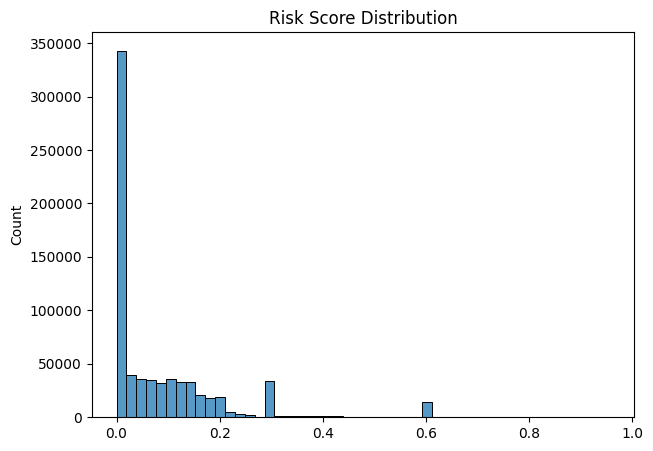

In [9]:
#Visualizations
plt.figure(figsize=(7,5))
sns.histplot(risk_score, bins=50)
plt.title("Risk Score Distribution")
plt.show()